# Figures 1 and 2: validation with square pulses

Companion to **Universal $\pi/2$ composite pulses**, H. G. Tonchev, P. Chernev,
A. A. Rangelov, and N. V. Vitanov, manuscript dated 24 September 2026.

This notebook propagates the fixed phase lists printed in Tables V, VI, and VII.
It reconstructs the physical-coordinate contour plots, checks every prescribed
Taylor cancellation (including mixed terms), and measures the disk areas in Eq. (18).
No phases are fitted, searched for, recalibrated, or optimized.

**Reproduction finding.** Tables VI and VII give UVH7a and UVH7d phases that differ
by at most $3\times10^{-15}\pi$. Their reconstructed probability landscapes must
therefore coincide to numerical precision. The two corresponding panels of the
printed Figure 2 differ visibly. This notebook retains the supplied phase lists
and reports the discrepancy; it does not modify phases to match the image.
Several other asymmetric panels appear horizontally reflected relative to the
stated Hamiltonian convention; the detuning-sign diagnostic below isolates that
second discrepancy.

Run all cells in order. Numerical arrays, figures, tables, and a provenance report
are written to `results/figures_1_2/`. The manuscript PDF is not needed at runtime.


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "uvh_validation").is_dir() and (p / "data/pulses.json").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from uvh_validation.catalog import CATALOG, CATALOG_PATH, phases
from uvh_validation.artifacts import write_csv, write_json, provenance
from uvh_validation.plotting import contour_figure, save_figure

def show_table(rows):
    keys = list(rows[0])
    lines = ["| " + " | ".join(keys) + " |", "| " + " | ".join(["---"] * len(keys)) + " |"]
    for row in rows:
        lines.append("| " + " | ".join(f"{row[k]:.7g}" if isinstance(row[k], float)
                                       else str(row[k]) for k in keys) + " |")
    display(Markdown("\n".join(lines)))


## 1. Published phase data and conventions

The appendix phase strings retain all 15 printed decimal places, in units of $\pi$.
The shorter main-text tables are not used. The primitive UVH1s has phase zero.
Lists are chronological: $U_{\rm CP}=U_{\phi_N}\cdots U_{\phi_1}$, acting on $|0\rangle$.
The plotted quantity is the population error $\Delta P=|P_1-1/2|$, not gate infidelity.


In [2]:
from uvh_validation.catalog import FIGURE1, FIGURE2
from uvh_validation.su2 import (square_primitive, square_to_universal, probability,
                                universal_probability)
from uvh_validation.validation import cancellation_report, disk_area_percent
OUT = ROOT / "results/figures_1_2"
OUT.mkdir(parents=True, exist_ok=True)
names = FIGURE1 + FIGURE2
show_table([dict(sequence=n, pulses=CATALOG[n]["pulse_count"],
                 cancelled_order=CATALOG[n]["cancelled_order"],
                 source=CATALOG[n]["source"], page=CATALOG[n]["page"]) for n in names])


| sequence | pulses | cancelled_order | source | page |
| --- | --- | --- | --- | --- |
| UVH1s | 1 | 0 | Eq. (19) | 4 |
| UVH5s | 5 | 1 | Table V | 16 |
| UVH7s | 7 | 1 | Table V | 16 |
| UVH9s | 9 | 2 | Table V | 16 |
| UVH11s | 11 | 2 | Table V | 16 |
| UVH13s | 13 | 3 | Table V | 16 |
| UVH4a | 4 | 1 | Table VI | 17 |
| UVH4d | 4 | 1 | Table VII | 20 |
| UVH5a | 5 | 1 | Table VI | 17 |
| UVH5d | 5 | 1 | Table VII | 20 |
| UVH6a | 6 | 1 | Table VI | 17 |
| UVH6d | 6 | 1 | Table VII | 20 |
| UVH7a | 7 | 2 | Table VI | 17 |
| UVH7d | 7 | 2 | Table VII | 20 |
| UVH8a | 8 | 2 | Table VI | 17 |
| UVH8d | 8 | 2 | Table VII | 20 |

## 2. Check the universal cancellation conditions

Equation (1), with $\beta=0$, is

$$U_\phi(\epsilon,\alpha)=\begin{pmatrix}
\sqrt{1/2-\epsilon}\,e^{i\alpha} & -i\sqrt{1/2+\epsilon}\,e^{i\phi}\\
-i\sqrt{1/2+\epsilon}\,e^{-i\phi} & \sqrt{1/2-\epsilon}\,e^{-i\alpha}
\end{pmatrix}.$$

The coefficient calculation implements Eqs. (10)-(12) using truncated bivariate
polynomial multiplication. It evaluates the supplied phases directly and uses no
finite-difference derivatives. For order $r$, the check requires $C_{00}=1/2$ and
$C_{mn}=0$ for **every** $1\le m+n\le r$. The tolerance $10^{-10}$ allows for
printed phase rounding and floating-point arithmetic. The leading RMS is Eq. (17),
including zero coefficients in its $q+1$ denominator.


In [3]:
cancellation, coefficients = cancellation_report(names)
show_table(cancellation)
assert all(row["passed"] for row in cancellation)
write_csv(OUT / "cancellation_checks.csv", cancellation)
write_csv(OUT / "taylor_coefficients.csv", coefficients)


| sequence | cancelled_order | target_error | max_cancelled_coefficient | leading_rms | passed |
| --- | --- | --- | --- | --- | --- |
| UVH1s | 0 | 1.110223e-16 | 0 | 0.7071068 | True |
| UVH5s | 1 | 1.221245e-15 | 1.221245e-15 | 0.8951833 | True |
| UVH7s | 1 | 1.44329e-15 | 4.007905e-14 | 0.4438704 | True |
| UVH9s | 2 | 1.554312e-15 | 2.997602e-15 | 2.284169 | True |
| UVH11s | 2 | 6.106227e-15 | 8.881784e-15 | 0.237027 | True |
| UVH13s | 3 | 9.992007e-16 | 1.110223e-14 | 4.225298 | True |
| UVH4a | 1 | 3.885781e-16 | 7.850462e-17 | 0.999194 | True |
| UVH4d | 1 | 0 | 5.551115e-17 | 1.14859 | True |
| UVH5a | 1 | 8.326673e-16 | 8.51424e-15 | 0.6086133 | True |
| UVH5d | 1 | 5.107026e-15 | 4.274359e-15 | 0.9783756 | True |
| UVH6a | 1 | 7.993606e-15 | 2.585432e-14 | 0.1624461 | True |
| UVH6d | 1 | 3.197442e-14 | 1.332268e-15 | 0.283809 | True |
| UVH7a | 2 | 4.440892e-16 | 4.558853e-15 | 3.386192 | True |
| UVH7d | 2 | 1.110223e-16 | 2.733924e-15 | 3.386192 | True |
| UVH8a | 2 | 2.164935e-15 | 9.769963e-15 | 0.1863047 | True |
| UVH8d | 2 | 6.661338e-16 | 2.88658e-15 | 0.5883971 | True |

## 3. Exact square-pulse model and physical grid

Section IV specifies
$$H_\phi/\hbar=\tfrac12(\Omega\cos\phi\,\sigma_x-
\Omega\sin\phi\,\sigma_y+\Delta\sigma_z).$$
Set $a=\Omega/\Omega_0$, $d=\Delta/\Omega_0$, and keep the primitive duration fixed
at $\Omega_0 T=\pi/2$. With $\rho=\sqrt{a^2+d^2}$,
$$U_\phi=\cos(\pi\rho/4)I-i\frac{\sin(\pi\rho/4)}{\rho}
\begin{pmatrix}d&a e^{i\phi}\\a e^{-i\phi}&-d\end{pmatrix}.$$

The grids cover exactly the axes of Figures 1 and 2: $-0.2\le d\le0.2$ and
$0.8\le a\le1.2$. A $601\times601$ grid is a numerical plotting choice, since
the manuscript does not specify its sampling. The propagator is analytic: no time
integration or time-step error enters these two figures.

The exact physical-to-universal map is $\epsilon=|U_{10}|^2-1/2$ and
$\alpha=\arg U_{00}$. The off-diagonal Cayley-Klein phase is zero on this domain.
This map is used as an independent cross-check, not as a linear approximation.


In [4]:
GRID_POINTS = 601
detuning = np.linspace(0.2, -0.2, GRID_POINTS)
amplitude = np.linspace(0.8, 1.2, GRID_POINTS)
D, A = np.meshgrid(detuning, amplitude, indexing="xy")
primitive = square_primitive(A, D)
probabilities = {name: probability(primitive, phases(name)) for name in names}
unitarity_error = float(np.max(np.abs(primitive.conj().swapaxes(-1, -2) @ primitive - np.eye(2))))
assert unitarity_error < 2e-14
for p in probabilities.values():
    assert np.min(p) >= -1e-13 and np.max(p) <= 1 + 1e-13
    assert abs(p[GRID_POINTS//2, GRID_POINTS//2] - 0.5) < 1e-12

small = primitive[::20, ::20]
epsilon, alpha = square_to_universal(small)
map_errors = {n: float(np.max(np.abs(universal_probability(epsilon, alpha, phases(n))
                                    - probabilities[n][::20, ::20]))) for n in names}
symmetry_errors = {n: float(np.max(np.abs(probabilities[n] - probabilities[n][:, ::-1])))
                   for n in FIGURE1}
assert max(map_errors.values()) < 2e-14
assert max(symmetry_errors.values()) < 2e-14
show_table([dict(check="unitarity", max_error=unitarity_error),
            dict(check="exact SU(2) coordinate map", max_error=max(map_errors.values())),
            dict(check="palindromic detuning symmetry", max_error=max(symmetry_errors.values()))])


| check | max_error |
| --- | --- |
| unitarity | 5.551499e-16 |
| exact SU(2) coordinate map | 3.441691e-15 |
| palindromic detuning symmetry | 4.551914e-15 |

## 4. Figure 1: palindromic sequences

Panel order follows Figure 1. Lines mark $\Delta P=10^{-6},\ldots,10^{-1}$.
Contours are extracted from the signed residual $P_1-1/2$ at both positive and
negative levels. This avoids losing thin contours across a zero crossing by
taking the absolute value before interpolation. Missing levels lie outside a
panel's attained error range.


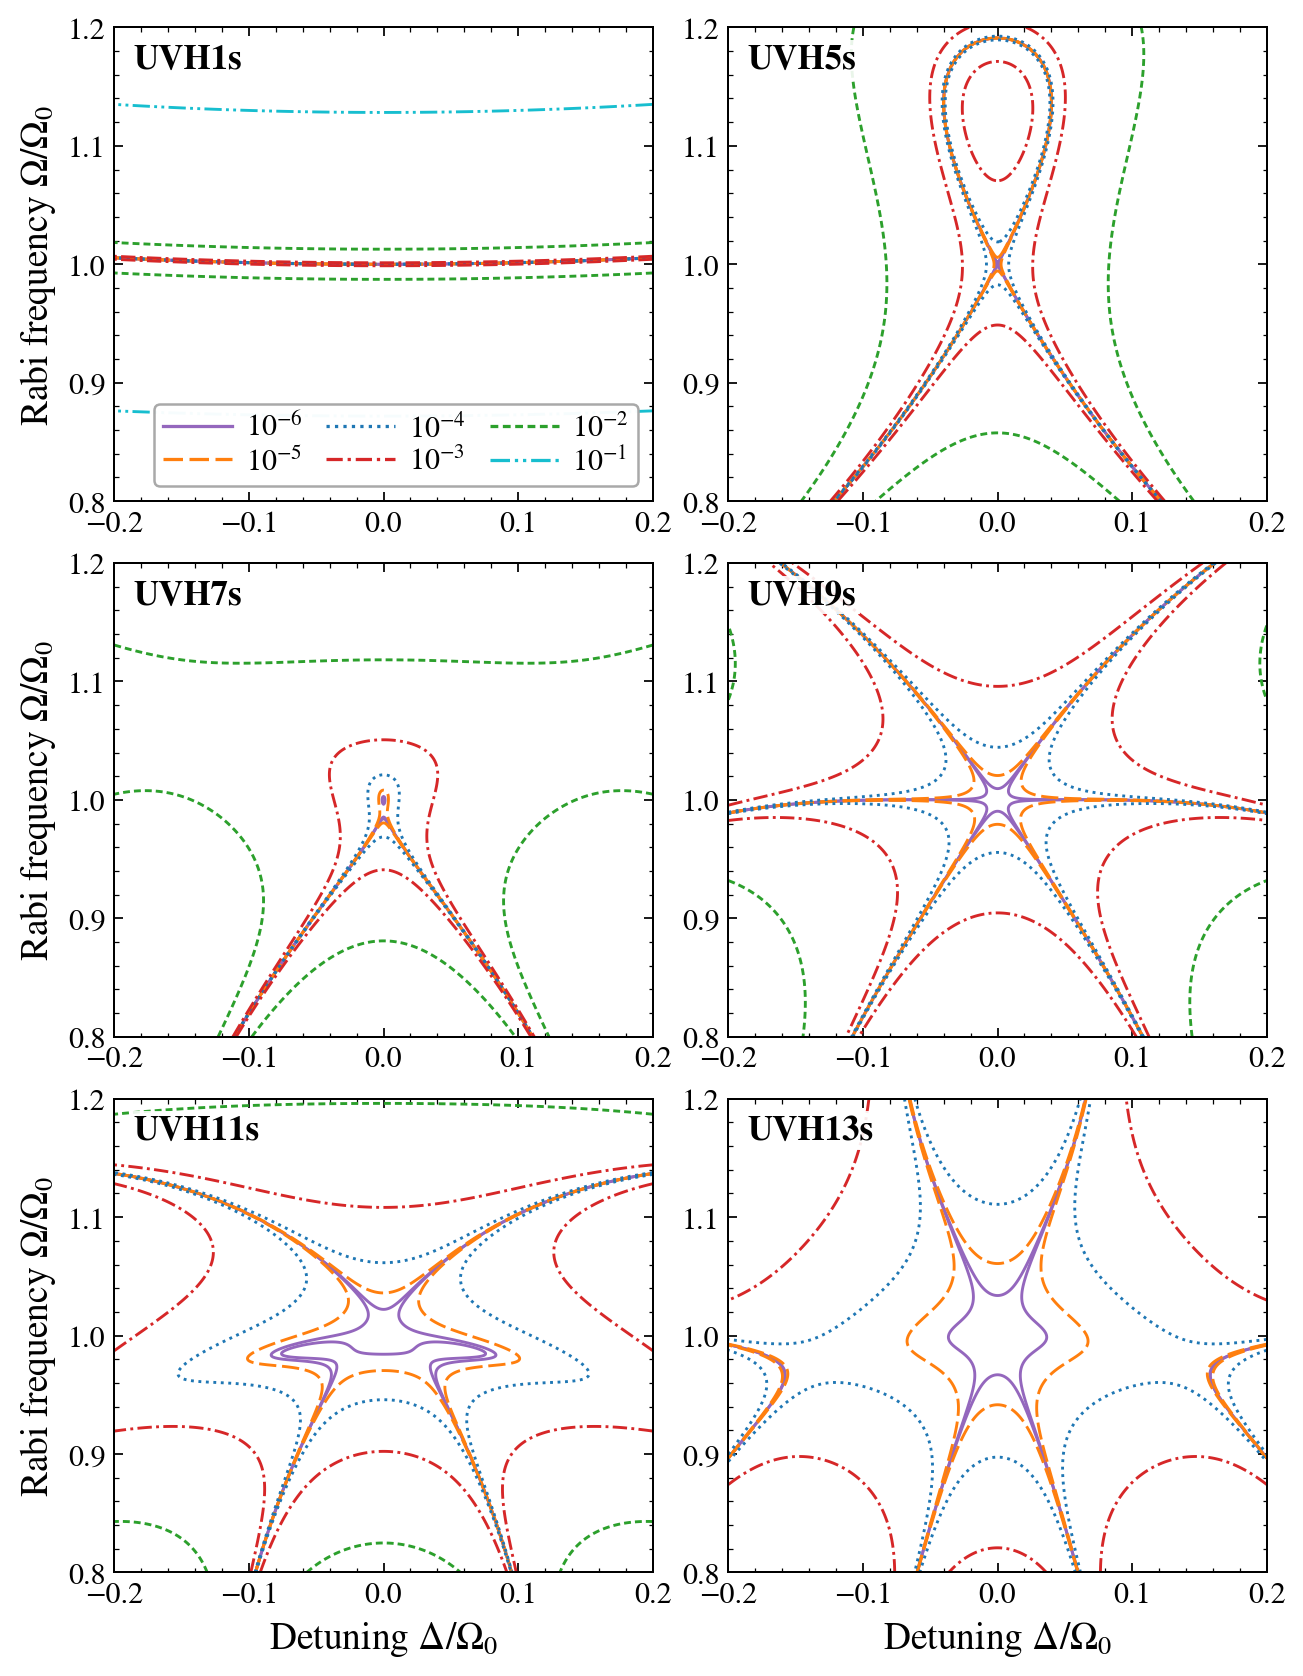

In [5]:
fig1 = contour_figure(detuning, amplitude,
                      [(n, probabilities[n] - 0.5) for n in FIGURE1], 3,
                      "Figure 1 | Palindromic square-pulse sequences")
save_figure(fig1, OUT, "sym_rms")
display(Image(filename=str(OUT / "sym_rms.png")))
plt.close(fig1)
np.savez_compressed(OUT / "sym_rms_data.npz", detuning_ratio=detuning,
                    amplitude_ratio=amplitude, **{n: probabilities[n] for n in FIGURE1})


## 5. Figure 2: the two supplied unrestricted families

The rows contain $N=4,5,6,7,8$. The family names describe how the manuscript's
phases were originally selected; this notebook only evaluates them. Both UVH7
panels below are necessarily identical for the appendix data.


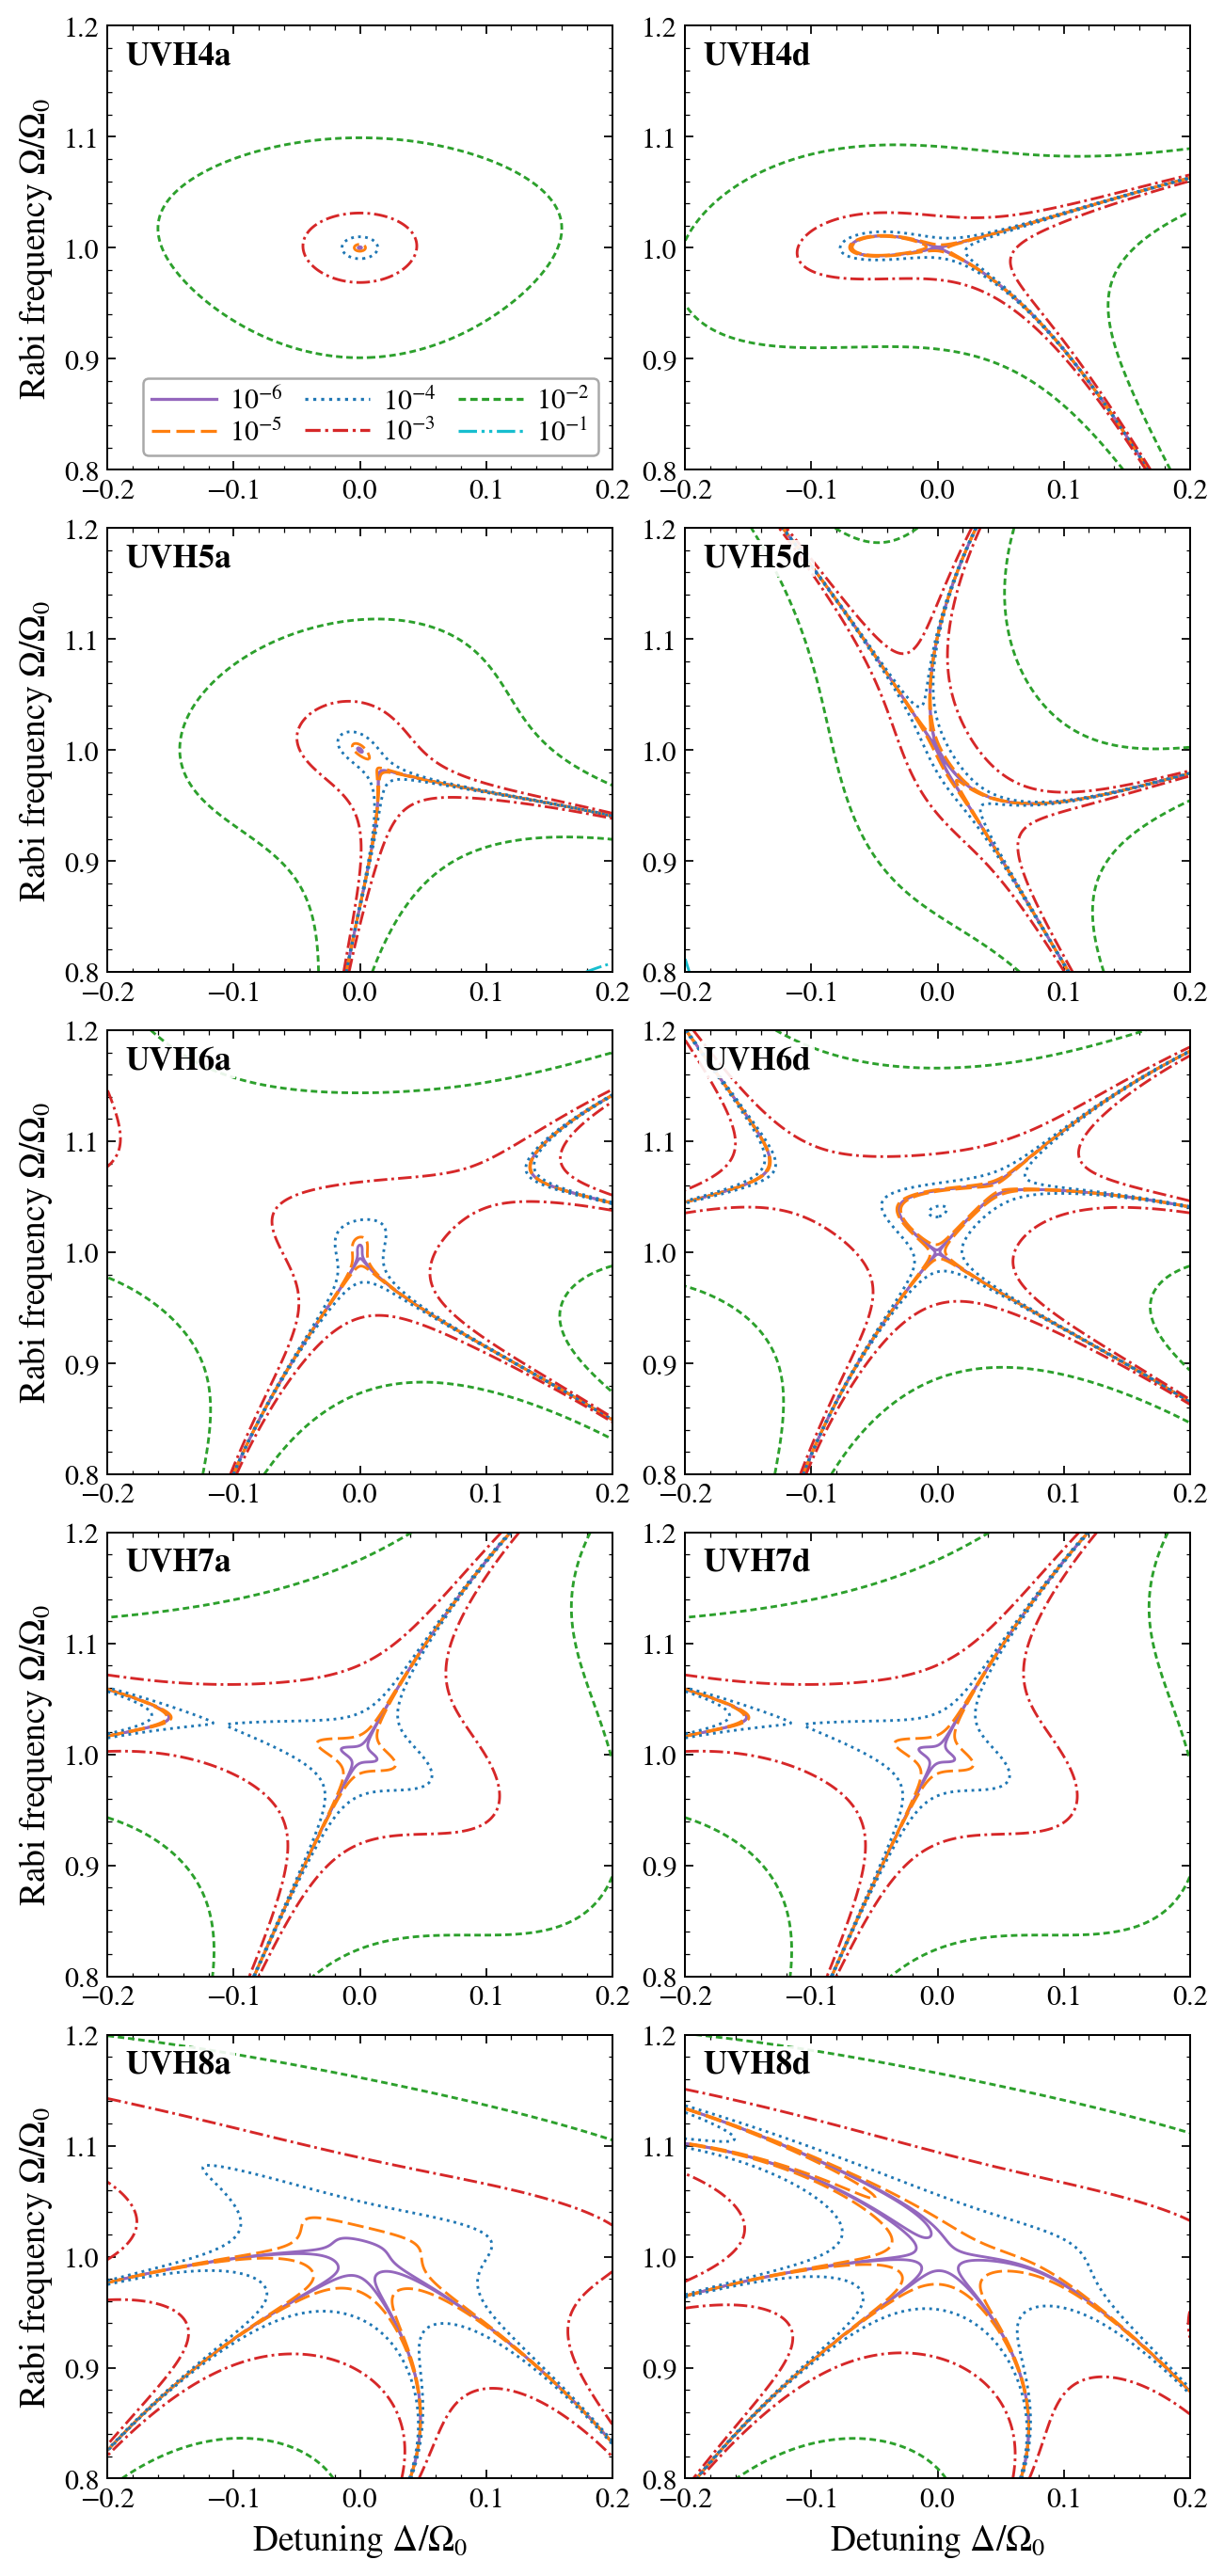

In [6]:
fig2 = contour_figure(detuning, amplitude,
                      [(n, probabilities[n] - 0.5) for n in FIGURE2], 5,
                      "Figure 2 | Unrestricted square-pulse sequences",
                      column_titles=["RMS-selected (a)", "Disk-area-selected (d)"])
save_figure(fig2, OUT, "rms_area")
display(Image(filename=str(OUT / "rms_area.png")))
plt.close(fig2)
np.savez_compressed(OUT / "rms_area_data.npz", detuning_ratio=detuning,
                    amplitude_ratio=amplitude, **{n: probabilities[n] for n in FIGURE2})

## 6. Verify finite-disk areas without changing the pulses

Equation (18) is evaluated in the **universal** $(\epsilon,\alpha)$ disk,
$\epsilon^2+\alpha^2\le0.2^2$, with threshold $10^{-4}$. These areas are not areas
in the physical axes of the figures. A scrambled Sobol rule maps a unit square
to the disk with $r=0.2\sqrt{u}$ and $\theta=2\pi v$, ensuring uniform area weight.

Two nested sample sizes and a second scramble diagnose sampling sensitivity.
Their spread is an empirical convergence diagnostic, not a rigorous error bound.
The reported Table VII values are rounded to 0.01 percentage points; agreement
is assessed at 0.03 percentage points, not at the last printed digit.


In [7]:
area_coarse = disk_area_percent(FIGURE2, sample_power=18, seed=20260924)
area_fine = disk_area_percent(FIGURE2, sample_power=20, seed=20260924)
area_repeat = disk_area_percent(FIGURE2, sample_power=20, seed=20260925)
area_rows = []
for name in FIGURE2:
    reference = CATALOG[name].get("reported_disk_area_percent")
    mean = (area_fine[name] + area_repeat[name])/2
    spread = max(area_coarse[name], area_fine[name], area_repeat[name]) - min(
                 area_coarse[name], area_fine[name], area_repeat[name])
    area_rows.append(dict(sequence=name, coarse_percent=area_coarse[name],
                          fine_percent=area_fine[name], repeat_percent=area_repeat[name],
                          mean_fine_percent=mean, empirical_spread_pp=spread,
                          #manuscript_percent=reference,
                          #difference_pp=None if reference is None else mean-reference
                          ))
show_table(area_rows)
write_csv(OUT / "disk_area_checks.csv", area_rows)


| sequence | coarse_percent | fine_percent | repeat_percent | mean_fine_percent | empirical_spread_pp |
| --- | --- | --- | --- | --- | --- |
| UVH4a | 0.2754211 | 0.2752304 | 0.2752304 | 0.2752304 | 0.0001907349 |
| UVH4d | 1.748657 | 1.740646 | 1.741409 | 1.741028 | 0.008010864 |
| UVH5a | 1.195908 | 1.187706 | 1.189327 | 1.188517 | 0.008201599 |
| UVH5d | 2.189255 | 2.1842 | 2.184868 | 2.184534 | 0.005054474 |
| UVH6a | 2.083206 | 2.083874 | 2.082062 | 2.082968 | 0.001811981 |
| UVH6d | 5.150223 | 5.156803 | 5.155373 | 5.156088 | 0.006580353 |
| UVH7a | 6.161499 | 6.155777 | 6.155968 | 6.155872 | 0.005722046 |
| UVH7d | 6.161499 | 6.155777 | 6.155968 | 6.155872 | 0.005722046 |
| UVH8a | 15.39421 | 15.39278 | 15.38744 | 15.39011 | 0.006771088 |
| UVH8d | 16.7675 | 16.77046 | 16.76645 | 16.76846 | 0.004005432 |